<a href="https://colab.research.google.com/github/Adarsh230305/Data_Science/blob/main/ford_car.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [27]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adhurimquku/ford-car-price-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ford-car-price-prediction' dataset.
Path to dataset files: /kaggle/input/ford-car-price-prediction


In [28]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [29]:
import os
file = os.listdir(path)[0]
df= pd.read_csv(os.path.join(path, file))
df.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0


In [30]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17966 entries, 0 to 17965
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   model         17966 non-null  object 
 1   year          17966 non-null  int64  
 2   price         17966 non-null  int64  
 3   transmission  17966 non-null  object 
 4   mileage       17966 non-null  int64  
 5   fuelType      17966 non-null  object 
 6   tax           17966 non-null  int64  
 7   mpg           17966 non-null  float64
 8   engineSize    17966 non-null  float64
dtypes: float64(2), int64(4), object(3)
memory usage: 1.2+ MB


In [31]:
df.describe()

,year,price,mileage,tax,mpg,engineSize
count,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000,17966.000000
mean,2016.866470,12279.534844,23362.608761,113.329456,57.906980,1.350807
std,2.050336,4741.343657,19472.054349,62.012456,10.125696,0.432367
min,1996.000000,495.000000,1.000000,0.000000,20.800000,0.000000
25%,2016.000000,8999.000000,9987.000000,30.000000,52.300000,1.000000
50%,2017.000000,11291.000000,18242.500000,145.000000,58.900000,1.200000
75%,2018.000000,15299.000000,31060.000000,145.000000,65.700000,1.500000
max,2060.000000,54995.000000,177644.000000,580.000000,201.800000,5.000000


In [32]:
df.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


In [33]:
df.shape

(17966, 9)

In [34]:
df.columns

Index(['model', 'year', 'price', 'transmission', 'mileage', 'fuelType', 'tax',
       'mpg', 'engineSize'],
      dtype='object')

<Axes: xlabel='price', ylabel='year'>

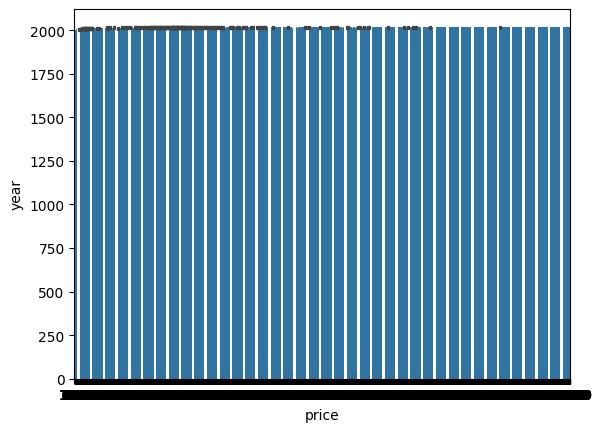

In [35]:
sns.barplot(df,x="price",y="year")

<Axes: xlabel='price', ylabel='model'>

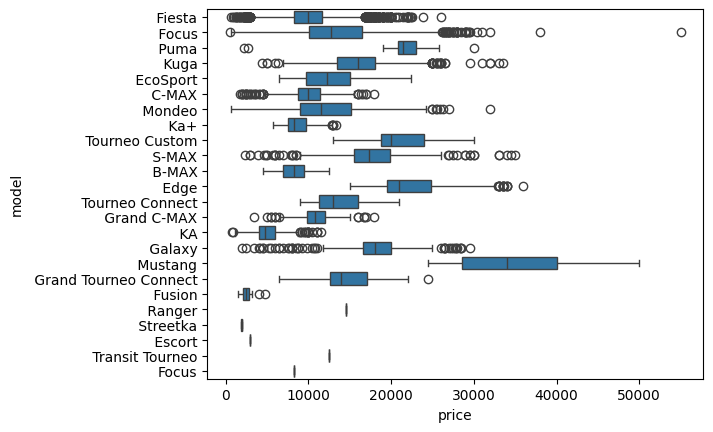

In [36]:
sns.boxplot(df,x="price",y='model')

<Axes: xlabel='price', ylabel='transmission'>

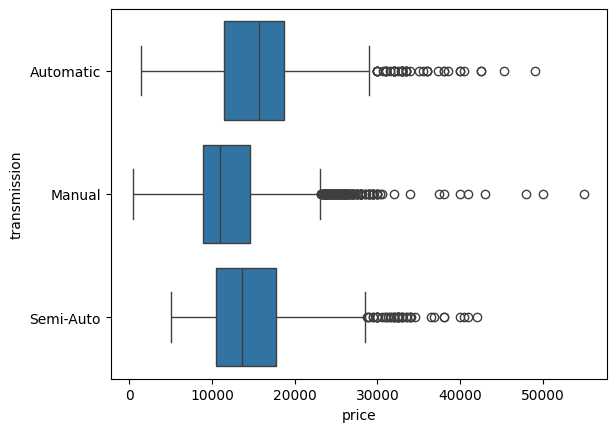

In [37]:
sns.boxplot(df,x="price",y="transmission")

<Axes: xlabel='price', ylabel='fuelType'>

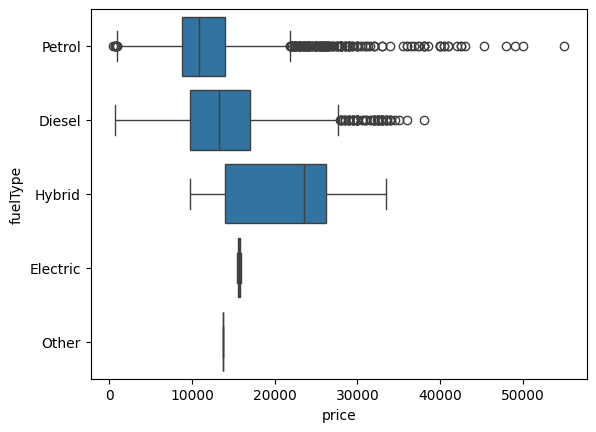

In [38]:
sns.boxplot(df,x="price",y="fuelType")

<Axes: xlabel='price', ylabel='mileage'>

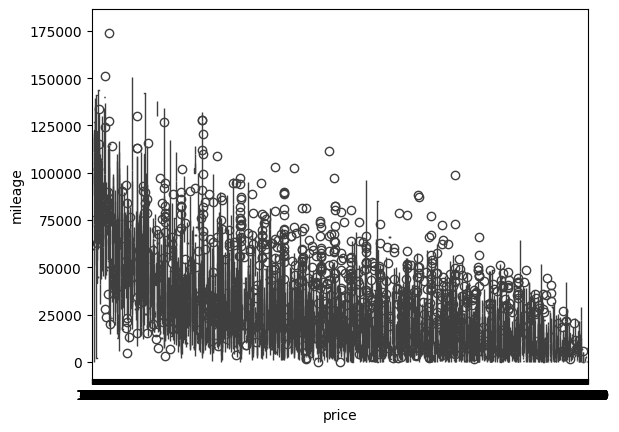

In [39]:
sns.boxplot(df,x="price",y="mileage")


<Axes: xlabel='price', ylabel='tax'>

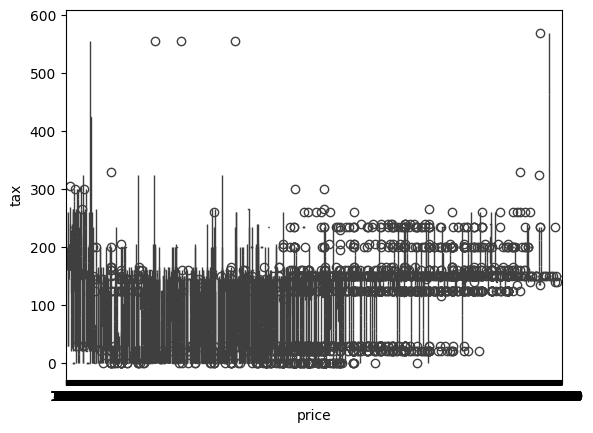

In [40]:
sns.boxplot(df,y="tax",x="price")

## data featuring

In [41]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


### Data preproccesing

#### by oneHot encoding

In [42]:
one_hot_encoded=pd.get_dummies(df,columns=["model","fuelType","transmission"],drop_first=True,dtype=int)
one_hot_encoded.head()

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,transmission_Manual,transmission_Semi-Auto
0,2017,12000,15944,150,57.7,1.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,2018,14000,9083,150,57.7,1.0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
2,2017,13000,12456,150,57.7,1.0,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
3,2019,17500,10460,145,40.3,1.5,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
4,2019,16500,1482,145,48.7,1.0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [43]:
df

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,Fiesta,2017,12000,Automatic,15944,Petrol,150,57.7,1.0
1,Focus,2018,14000,Manual,9083,Petrol,150,57.7,1.0
2,Focus,2017,13000,Manual,12456,Petrol,150,57.7,1.0
3,Fiesta,2019,17500,Manual,10460,Petrol,145,40.3,1.5
4,Fiesta,2019,16500,Automatic,1482,Petrol,145,48.7,1.0
...,...,...,...,...,...,...,...,...,...
17961,B-MAX,2017,8999,Manual,16700,Petrol,150,47.1,1.4
17962,B-MAX,2014,7499,Manual,40700,Petrol,30,57.7,1.0
17963,Focus,2015,9999,Manual,7010,Diesel,20,67.3,1.6
17964,KA,2018,8299,Manual,5007,Petrol,145,57.7,1.2


#### via label encoding

In [44]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
xlabel_encoded=df.copy()
cols=["model","transmission","fuelType"]
for x in cols:
 xlabel_encoded[x]=le.fit_transform(xlabel_encoded[x].astype(str))
xlabel_encoded.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,5,2017,12000,0,15944,4,150,57.7,1.0
1,6,2018,14000,1,9083,4,150,57.7,1.0
2,6,2017,13000,1,12456,4,150,57.7,1.0
3,5,2019,17500,1,10460,4,145,40.3,1.5
4,5,2019,16500,0,1482,4,145,48.7,1.0


#### Standard scaling

In [45]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
numeric_cols=["mileage","tax","mpg","engineSize","year"]
one_hot_encoded[numeric_cols]=scaler.fit_transform(one_hot_encoded[numeric_cols])
one_hot_encoded.head()

,year,price,mileage,tax,mpg,engineSize,model_ C-MAX,model_ EcoSport,model_ Edge,model_ Escort,...,model_ Tourneo Connect,model_ Tourneo Custom,model_ Transit Tourneo,model_Focus,fuelType_Electric,fuelType_Hybrid,fuelType_Other,fuelType_Petrol,transmission_Manual,transmission_Semi-Auto
0,0.065128,12000,-0.380998,0.591358,-0.020442,-0.811386,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
1,0.552866,14000,-0.733359,0.591358,-0.020442,-0.811386,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
2,0.065128,13000,-0.560132,0.591358,-0.020442,-0.811386,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
3,1.040605,17500,-0.662640,0.510727,-1.738890,0.345070,0,0,0,0,...,0,0,0,0,0,0,0,1,1,0
4,1.040605,16500,-1.123724,0.510727,-0.909294,-0.811386,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


In [53]:
xlabel_encoded.isnull().sum()

,0
model,0
year,0
price,0
transmission,0
mileage,0
fuelType,0
tax,0
mpg,0
engineSize,0


In [59]:
numeric_columns=xlabel_encoded.drop(columns="price").columns
numeric_columns

xlabel_encoded[numeric_columns]=scaler.fit_transform(xlabel_encoded[numeric_columns])
xlabel_encoded.head()

,model,year,price,transmission,mileage,fuelType,tax,mpg,engineSize
0,-0.460699,0.065128,12000,-2.670032,-0.380998,0.688777,0.591358,-0.020442,-0.811386
1,-0.211477,0.552866,14000,0.041351,-0.733359,0.688777,0.591358,-0.020442,-0.811386
2,-0.211477,0.065128,13000,0.041351,-0.560132,0.688777,0.591358,-0.020442,-0.811386
3,-0.460699,1.040605,17500,0.041351,-0.662640,0.688777,0.510727,-1.738890,0.345070
4,-0.460699,1.040605,16500,-2.670032,-1.123724,0.688777,0.510727,-0.909294,-0.811386


## making linear regression model

In [66]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
model1=LinearRegression()
X=one_hot_encoded.drop(columns="price")
y=one_hot_encoded['price']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
model1.fit(X_train,y_train)
y_pred=model1.predict(X_test)
r2=r2_score(y_test,y_pred)
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
print("Adjusted R² Score %:", adjusted_r2*100)
print("one_hot_model_r2 score % : ",r2*100)

Adjusted R² Score %: 83.92882534566236
one_hot_model_r2 score % :  84.02100144860559


In [67]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
model2=LinearRegression()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33, random_state=42)
model2.fit(X_train,y_train)
y_pred=model2.predict(X_test)
r2=r2_score(y_pred,y_test)
n = X_test.shape[0]
p = X_test.shape[1]
adjusted_r2 = 1 - ((1 - r2) * (n - 1)) / (n - p - 1)
print("Adjusted R² Score %:", adjusted_r2*100)
print("Label_encoded model r2 score %: ",r2*100)

Adjusted R² Score %: 80.88705983078086
Label_encoded model r2 score %:  80.9966819572575


In [64]:
print("we can see model1(one_hot_encoded) is more efficient")

we can see model1(one_hot_encoded) is more efficient
